<a href="https://colab.research.google.com/github/MridulaRPanicker/ICT_Exit-test/blob/main/ICT_Exit_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Section A : Data Wrangling & Exploratory Analysis**



####Q1: Load the dataset and perform an initial audit. Report the shape, data types, and count of missing values per column. Then clean the dataset by: (a) dropping rows with missing location or size, and (b) filling missing bath and balcony values with their column medians.

In [30]:
# Initial setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# loading the Bengaluru_House_Data.csv for analysis and prediction

house_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bengaluru_House_Data.csv')

# Initial evaluation of data

house_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [32]:
# printing shape and datatypes of the dataset
print(f"Shape of the dataset is : {house_data.shape}\n")
print(f"Data Types of columns\n\n{house_data.dtypes}")


Shape of the dataset is : (13320, 9)

Data Types of columns

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [33]:
# Checking for missing values

house_data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [34]:
# Cleaning
# (a) dropping rows with missing location or size

# missing 1 row for 'location' and 16 rows for 'size'. So there will be 17 records less after removing these missing rows.

house_data.dropna(subset=['location', 'size'], inplace=True)
print(house_data.isnull().sum())
print(f"\nNew Shape of dataset: {house_data.shape}")

area_type          0
availability       0
location           0
size               0
society         5499
total_sqft         0
bath              57
balcony          593
price              0
dtype: int64

New Shape of dataset: (13303, 9)


In [35]:
# (b) filling missing bath and balcony values with their column medians.

house_data['bath'] = house_data['bath'].fillna(house_data['bath'].median())
house_data['balcony'] = house_data['balcony'].fillna(house_data['balcony'].median())
print(house_data.isnull().sum())

area_type          0
availability       0
location           0
size               0
society         5499
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64


In [36]:
house_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#### Q2 The size column contains values like "2 BHK" and "3 Bedroom". Extract only the numeric part and store it as a new integer column called bhk. Similarly, the total_sqft column has some range entries like "1000-1200". Convert these ranges to their average and ensure the entire column is numeric.

In [37]:
# Extract only the numeric column from "Size" and make a new column "bhk" with these values

# .split() splits the string by whitespace and str[0] takes the first element split created and then converted it into 'int' type
house_data['bhk'] = house_data['size'].str.split().str[0].astype(int)
house_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2


In [45]:
# if there is any range values in the column 'total_sqft' changing it to the average
# Converting the 'total_sqft' column to numeric

# to clean the values in 'total_sqft' look for '-' in the values and find the average

def sqft_num(x):
  sqft_range = str(x).split('-')
  if len(sqft_range) == 2:
    return (float(sqft_range[0]) + float(sqft_range[1]))/2

  try:
    return float(x)
  except:
    return None


house_data['total_sqft'] = house_data['total_sqft'].apply(sqft_num)

In [46]:
house_data.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,5499
total_sqft,46
bath,0
balcony,0
price,0
bhk,0


In [48]:
house_data['total_sqft'] = house_data['total_sqft'].fillna(house_data['total_sqft'].median())
house_data.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,5499
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


In [49]:
house_data.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,float64
bath,float64
balcony,float64
price,float64
bhk,int64


#### Q3 Create a new feature price_per_sqft = price x 100000 / total_sqft. Identify and remove outliers where price_per_sqft is beyond mean +/- 3 standard deviations within each location group. Report how many rows were removed and why this location-wise approach is preferred over a global threshold.

In [52]:
# New feature price_per_sqft

house_data['price_per_sqft'] = round((house_data['price'] * 100000) / house_data['total_sqft'],2)

In [53]:
house_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.81
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.38
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,4305.56
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.89
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,4250.00


In [54]:
# Need to remove outliers based on location

# calculating mean and SD for each location
stats = house_data.groupby('location')['price_per_sqft'].agg(['mean', 'std'])

# mapping the stats to the corresponding rows
house_data = house_data.join(stats, on='location')

# Filter rows where price_per_sqft is within mean +/- 3 standard deviations
initial_count = len(house_data)

# We use the calculated mean and std columns for the logic
house_data = house_data[
    (house_data['price_per_sqft'] > (house_data['mean'] - 3 * house_data['std'])) &
    (house_data['price_per_sqft'] <= (house_data['mean'] + 3 * house_data['std']))
]

# 4. Clean up the temporary mean/std columns and report
house_data = house_data.drop(['mean', 'std'], axis=1)
rows_removed = initial_count - len(house_data)

print(f"Rows removed: {rows_removed}")

Rows removed: 641


In [61]:
house_data.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,12662.000000,12662.000000,12662.000000,12662.000000,12662.000000,1.266200e+04
mean,1553.845283,2.645238,1.603301,109.234444,2.756279,6.741647e+03
std,1234.750640,1.259241,0.799770,144.151960,1.209573,2.170518e+04
min,5.000000,1.000000,0.000000,8.000000,1.000000,2.678300e+02
25%,1100.000000,2.000000,1.000000,49.872500,2.000000,4.250000e+03
50%,1276.000000,2.000000,2.000000,70.000000,3.000000,5.380915e+03
75%,1670.000000,3.000000,2.000000,115.000000,3.000000,7.128722e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,2.300000e+06


####Report how many rows were removed and why this location-wise approach is preferred over a global threshold.

641 rows were removed which doesn't follow the condition.

In the case of real estate the price_per_sqft depends on location. The price_per_sqft will be very high for an expensive location compared to a rural area. So if we apply a global rule, some price_per_sqft will look like an outlier, but in reality that is the speciality of a particular location. So better to do it location wise.


#### Q4 Produce the following visualizations with proper titles, labels, and color encoding:
• Distribution of price_per_sqft (histogram + KDE overlay)

• Correlation heatmap of all numeric features

• Box plot of price across bhk categories

Note: Comment on one key insight observed from each plot.

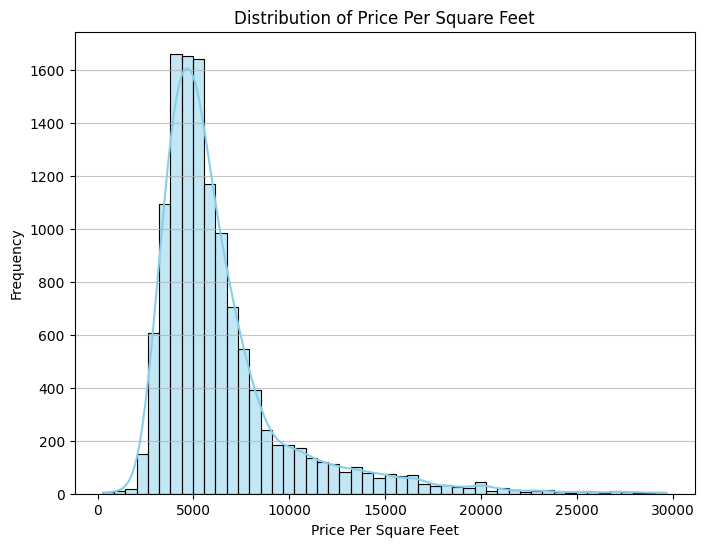

In [62]:
# Distribution of price_per_sqft (histogram + KDE overlay)
filtered_data = house_data[house_data['price_per_sqft'] < 30000]
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data['price_per_sqft'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Price Per Square Feet')
plt.xlabel('Price Per Square Feet')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

####Insight:
The distribution of price_per_sqft appears right-skewed, indicating that most properties have a lower price per square foot, with a long tail extending towards higher values. This is typical for real estate markets where a few luxury properties have very higher prices.

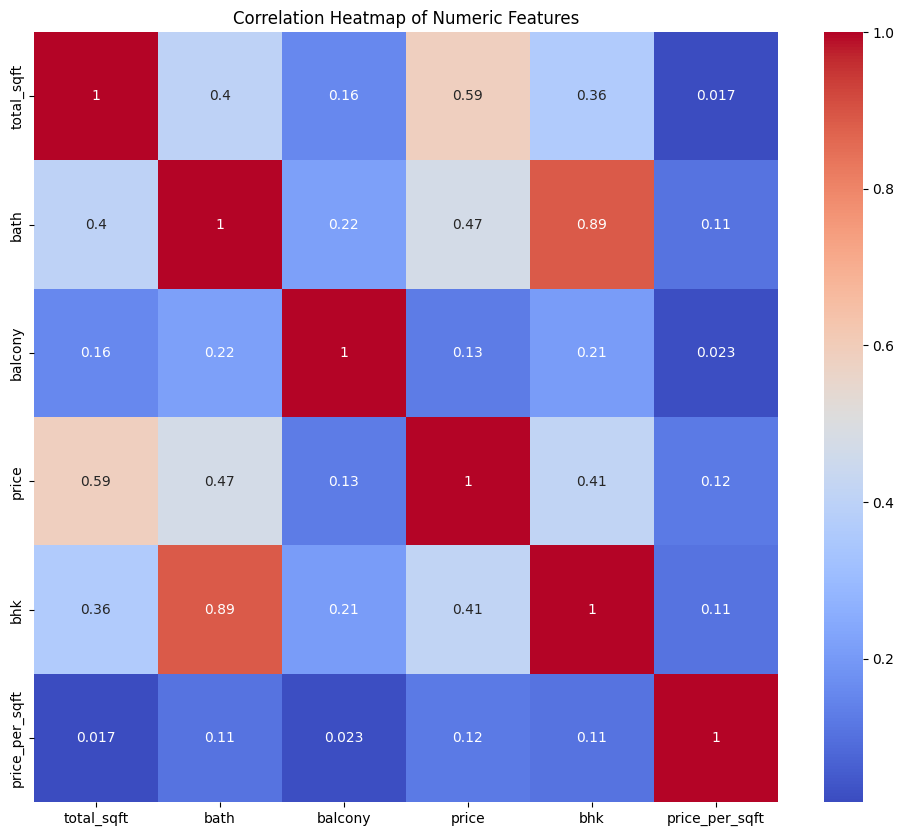

In [64]:
from numpy._core import numeric
# Correlation heatmap of all numeric features
plt.figure(figsize=(12, 10))
numeric_columns = house_data.select_dtypes(include=[np.number]).columns
sns.heatmap(house_data[numeric_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


There is the strongest correlation between bath and bhk. It is logical because these two features increases the sqft and finally decides the price of the real estate.
total_sqft is the primary feature which affects the price.


/tmp/ipykernel_2312/3656710943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bhk', y='price', data=house_data, palette='viridis')


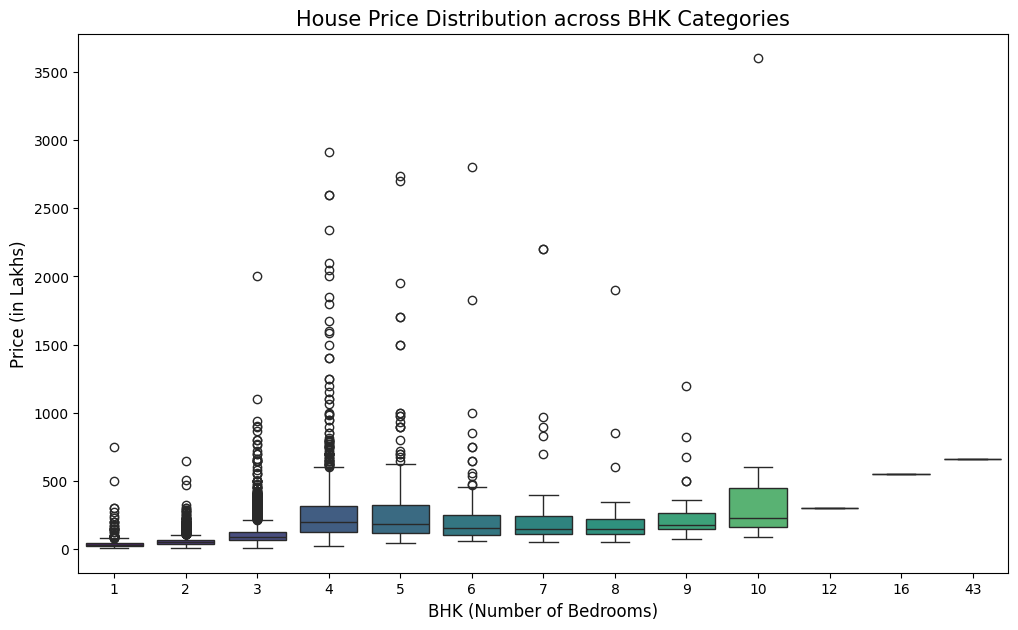

In [66]:
# Box plot of price across bhk categories

plt.figure(figsize=(12, 7))
sns.boxplot(x='bhk', y='price', data=house_data, palette='viridis')
plt.title('House Price Distribution across BHK Categories', fontsize=15)
plt.xlabel('BHK (Number of Bedrooms)', fontsize=12)
plt.ylabel('Price (in Lakhs)', fontsize=12)
plt.show()

The median price is increasing as the number of bedrooms increases.

3,4,5 BHKs show outliers. This should be due to the location of the property.

There could be data entry error as it is showing 43 bhk.

#### Q5 Apply one-hot encoding on area_type and label encoding on the top 20 most frequent locations (map all others to "Other"). Apply Min-Max scaling to total_sqft and bath. Briefly justify why you chose these encoding and scaling strategies for each column.

In [67]:
# One-hot encoding for 'area_type'

area_type_dummies = pd.get_dummies(house_data['area_type'], prefix='area_type')
house_data = pd.concat([house_data, area_type_dummies], axis=1)
house_data.drop('area_type', axis=1, inplace=True)

print("One-hot encoding for 'area_type' applied. New columns added:")
house_data.head()

One-hot encoding for 'area_type' applied. New columns added:


,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.81,False,False,False,True
1,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.38,False,False,True,False
2,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,4305.56,True,False,False,False
3,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.89,False,False,False,True
4,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,4250.00,False,False,False,True


In [68]:
# Label encoding on the top 20 most frequent locations (map all others to 'Other')

top_20_locations = house_data['location'].value_counts().nlargest(20).index
house_data['location_encoded'] = house_data['location'].apply(lambda x: x if x in top_20_locations else 'Other')

# Now apply label encoding to the new 'location_encoded' column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
house_data['location_encoded'] = le.fit_transform(house_data['location_encoded'])

house_data.drop('location', axis=1, inplace=True)
print("\nLabel encoding for 'location' applied. Top 20 locations identified, others mapped to 'Other'.")
print(f"Number of unique locations after encoding: {len(house_data['location_encoded'].unique())}")


Label encoding for 'location' applied. Top 20 locations identified, others mapped to 'Other'.
Number of unique locations after encoding: 21


In [69]:
house_data.head()

,availability,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_encoded
0,19-Dec,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.81,False,False,False,True,5
1,Ready To Move,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.38,False,False,True,False,13
2,Ready To Move,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,4305.56,True,False,False,False,18
3,Ready To Move,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.89,False,False,False,True,13
4,Ready To Move,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,4250.00,False,False,False,True,13


In [70]:
# Min-Max scaling to 'total_sqft' and 'bath'

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

house_data[['total_sqft', 'bath']] = scaler.fit_transform(house_data[['total_sqft', 'bath']])

print("\nMin-Max scaling applied to 'total_sqft' and 'bath'.")
print("\nFirst 5 rows of the preprocessed data:")



Min-Max scaling applied to 'total_sqft' and 'bath'.

First 5 rows of the preprocessed data:


In [71]:
house_data.head()

,availability,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_encoded
0,19-Dec,2 BHK,Coomee,0.020108,0.025641,1.0,39.07,2,3699.81,False,False,False,True,5
1,Ready To Move,4 Bedroom,Theanmp,0.049649,0.102564,3.0,120.00,4,4615.38,False,False,True,False,13
2,Ready To Move,3 BHK,NaN,0.027455,0.025641,3.0,62.00,3,4305.56,True,False,False,False,18
3,Ready To Move,3 BHK,Soiewre,0.029005,0.051282,1.0,95.00,3,6245.89,False,False,False,True,13
4,Ready To Move,2 BHK,NaN,0.022863,0.025641,1.0,51.00,2,4250.00,False,False,False,True,13


**### Section B Supervised Learning**

#### Q6 Train a Linear Regression model to predict price using all prepared features. Use an 80/20 train-test split (random_state=42). Report RMSE, MAE, and R-squared on the test set. Then train Ridge and Lasso regression models with the same split and compare all three in a results table. Explain why regularisation is beneficial in this context.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Droppin availability and society, since it has so many missing values and not useful for model training.
# Dropping price as it is the target feature.

X = house_data.drop(columns=['price', 'availability', 'size', 'society','price_per_sqft'])
y = house_data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (10129, 9)
Test set shape: (2533, 9)


### Linear Regression Model

In [75]:
# Train Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Evaluate Linear Regression Model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - RMSE: {rmse_linear:.2f}")
print(f"Linear Regression - MAE: {mae_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

Linear Regression - RMSE: 98.66
Linear Regression - MAE: 40.61
Linear Regression - R-squared: 0.53


### Ridge Regression Model

In [76]:
# Train Ridge Regression Model
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Regression Model
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - RMSE: {rmse_ridge:.2f}")
print(f"Ridge Regression - MAE: {mae_ridge:.2f}")
print(f"Ridge Regression - R-squared: {r2_ridge:.2f}")

Ridge Regression - RMSE: 102.12
Ridge Regression - MAE: 41.70
Ridge Regression - R-squared: 0.50


### Lasso Regression Model

In [77]:
# Train Lasso Regression Model
lasso_model = Lasso(random_state=42)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate Lasso Regression Model
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - RMSE: {rmse_lasso:.2f}")
print(f"Lasso Regression - MAE: {mae_lasso:.2f}")
print(f"Lasso Regression - R-squared: {r2_lasso:.2f}")

Lasso Regression - RMSE: 119.36
Lasso Regression - MAE: 50.76
Lasso Regression - R-squared: 0.31


### Comparison of Models

In [78]:
# Create a results table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [rmse_linear, rmse_ridge, rmse_lasso],
    'MAE': [mae_linear, mae_ridge, mae_lasso],
    'R-squared': [r2_linear, r2_ridge, r2_lasso]
})

display(results.round(2))

,Model,RMSE,MAE,R-squared
0,Linear Regression,98.66,40.61,0.53
1,Ridge Regression,102.12,41.70,0.50
2,Lasso Regression,119.36,50.76,0.31


###Why Regularization is Beneficial

Regularization helps to prevent overfitting by adding a penalty term to the loss function.

1.  This helps in eliminating over fitting. Otherwise Linear Regression try to remember all the features and give unwanted importance to some. This affects performance on unseen data.

2. Lasso helps to eliminate the importance of magnetude.
3. Ridge helps to eliminate the importance of highly correlated features.

4.  Improved Generalization: By constraining the magnitude of coefficients, both Ridge and Lasso models tend to generalize better to new, unseen data compared to unregularized Linear Regression, especially in cases with a large number of features relative to the number of samples, or when features are noisy.

#### Q7 Create a binary classification target: high_value = 1 if price >= 100 lakhs, else 0. Train a Logistic Regression and a Naive Bayes classifier on this target. Report accuracy, precision, recall, and F1-score for both. Plot the confusion matrix for the better-performing model.

In [79]:
# Create the binary target variable 'high_value'
house_data['high_value'] = (house_data['price'] >= 100).astype(int)

# Define features (X) and the new target (y) for classification
X_clas = house_data.drop(columns=['price', 'high_value', 'availability', 'size', 'society', 'price_per_sqft'])
y_clas = house_data['high_value']

# Split the data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clas, y_clas, test_size=0.2, random_state=42)

print(f"High value properties distribution:\n{y_clas.value_counts(normalize=True)}")
print(f"\nTraining set shape for classification: {X_train_clf.shape}")
print(f"Test set shape for classification: {X_test_clf.shape}")

High value properties distribution:
high_value
0    0.691044
1    0.308956
Name: proportion, dtype: float64

Training set shape for classification: (10129, 9)
Test set shape for classification: (2533, 9)


### Logistic Regression Classifier

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification
log_reg_model.fit(X_train_clf, y_train_clf)
y_pred_log_reg = log_reg_model.predict(X_test_clf)

# Evaluate Logistic Regression Model
accuracy_log_reg = accuracy_score(y_test_clf, y_pred_log_reg)
precision_log_reg = precision_score(y_test_clf, y_pred_log_reg)
recall_log_reg = recall_score(y_test_clf, y_pred_log_reg)
f1_log_reg = f1_score(y_test_clf, y_pred_log_reg)

print("Logistic Regression Classification Report:")
print(classification_report(y_test_clf, y_pred_log_reg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1726
           1       0.87      0.48      0.62       807

    accuracy                           0.81      2533
   macro avg       0.84      0.72      0.75      2533
weighted avg       0.82      0.81      0.79      2533



### Naive Bayes Classifier (GaussianNB)

In [81]:
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train_clf, y_train_clf)
y_pred_nb = nb_model.predict(X_test_clf)

# Evaluate Naive Bayes Model
accuracy_nb = accuracy_score(y_test_clf, y_pred_nb)
precision_nb = precision_score(y_test_clf, y_pred_nb)
recall_nb = recall_score(y_test_clf, y_pred_nb)
f1_nb = f1_score(y_test_clf, y_pred_nb)

print("Naive Bayes Classification Report:")
print(classification_report(y_test_clf, y_pred_nb))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1726
           1       0.80      0.64      0.71       807

    accuracy                           0.83      2533
   macro avg       0.82      0.78      0.80      2533
weighted avg       0.83      0.83      0.83      2533



### Comparison and Confusion Matrix for the Better Model

Compare the F1-scores of both models to determine the better-performing one. F1-score is a good metric to use when there's an imbalance in class distribution (which we have here, with more low-value properties).

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.81,0.87,0.48,0.62
1,Naive Bayes,0.83,0.80,0.64,0.71



The better-performing model based on F1-score is: Naive Bayes


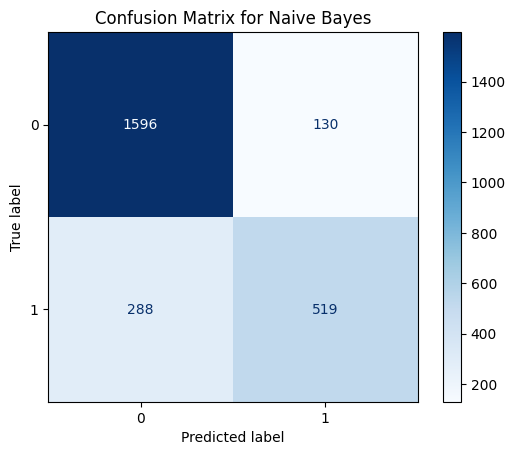


Justification for choosing Naive Bayes:
Naive Bayes demonstrated a higher F1-score (0.71) compared to the other model. F1-score is particularly relevant here because it balances precision and recall, which is important given the class imbalance. This means it provides a better overall measure of the model's ability to correctly classify both 'high_value' and 'low_value' properties.


In [82]:
# Create a results table for classification models
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy_log_reg, accuracy_nb],
    'Precision': [precision_log_reg, precision_nb],
    'Recall': [recall_log_reg, recall_nb],
    'F1-Score': [f1_log_reg, f1_nb]
})

display(classification_results.round(2))

# Determine the better performing model based on F1-score
if f1_log_reg > f1_nb:
    best_model_name = 'Logistic Regression'
    best_y_pred = y_pred_log_reg
    best_model_metrics = classification_results.loc[classification_results['Model'] == 'Logistic Regression'].iloc[0]
else:
    best_model_name = 'Naive Bayes'
    best_y_pred = y_pred_nb
    best_model_metrics = classification_results.loc[classification_results['Model'] == 'Naive Bayes'].iloc[0]

print(f"\nThe better-performing model based on F1-score is: {best_model_name}")

# Plot Confusion Matrix for the better-performing model
cm = confusion_matrix(y_test_clf, best_y_pred, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # 0: Low Value, 1: High Value
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

print(f"\nJustification for choosing {best_model_name}:\n{best_model_name} demonstrated a higher F1-score ({best_model_metrics['F1-Score']:.2f}) compared to the other model. F1-score is particularly relevant here because it balances precision and recall, which is important given the class imbalance. This means it provides a better overall measure of the model's ability to correctly classify both 'high_value' and 'low_value' properties.")

####Q8 Train a Random Forest classifier on the same binary target. Use GridSearchCV with 5-fold cross-validation to tune n_estimators (50, 100, 200) and max_depth (None, 5, 10). Report the best parameters, best cross-val score, and test set metrics. Plot feature importances as a horizontal bar chart.

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# 2. Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10] # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
}

# 3. Initialize GridSearchCV
# We will use 'f1' as the scoring metric due to class imbalance
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)

# 4. Fit GridSearchCV on the training data
grid_search.fit(X_train_clf, y_train_clf)

# 5. Report best parameters and best cross-validation score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 score: {grid_search.best_score_:.2f}")

# 6. Get the best model
best_rf_model = grid_search.best_estimator_

# 7. Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test_clf)

# 8. Report test set metrics
print("\nRandom Forest Classifier Test Set Metrics:")
print(classification_report(y_test_clf, y_pred_rf))

accuracy_rf = accuracy_score(y_test_clf, y_pred_rf)
precision_rf = precision_score(y_test_clf, y_pred_rf)
recall_rf = recall_score(y_test_clf, y_pred_rf)
f1_rf = f1_score(y_test_clf, y_pred_rf)

rf_results = pd.DataFrame({
    'Model': ['Random Forest'],
    'Accuracy': [accuracy_rf],
    'Precision': [precision_rf],
    'Recall': [recall_rf],
    'F1-Score': [f1_rf]
})
display(rf_results.round(2))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best cross-validation F1 score: 0.81

Random Forest Classifier Test Set Metrics:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1726
           1       0.85      0.82      0.83       807

    accuracy                           0.90      2533
   macro avg       0.88      0.88      0.88      2533
weighted avg       0.90      0.90      0.90      2533



,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9,0.85,0.82,0.83


### Feature Importances

/tmp/ipykernel_2312/2148465688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


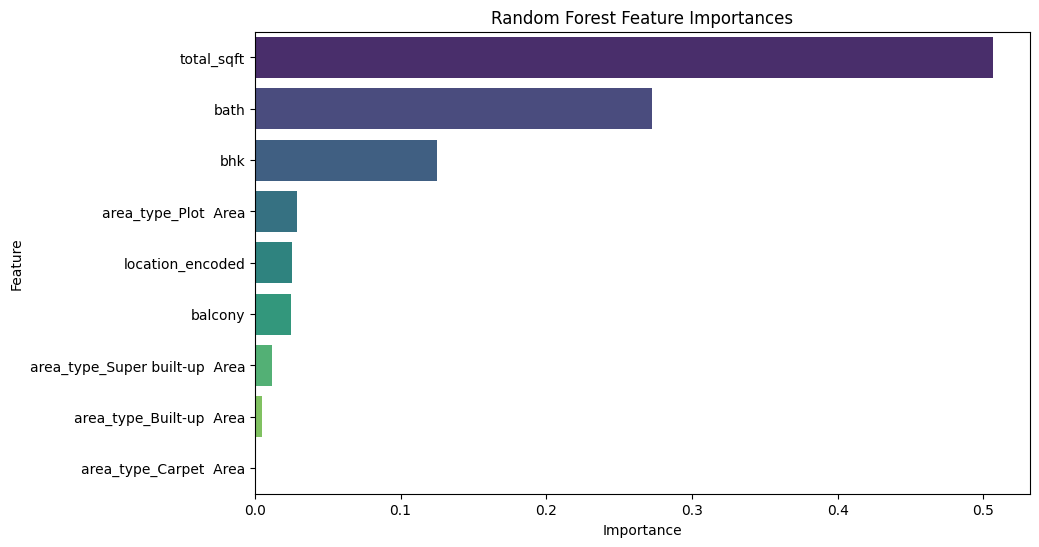

In [84]:
# Plot feature importances
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train_clf.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**###Section C Unsupervised Learning & Dimensionality Reduction**

#### Q9 Apply K-Means clustering on total_sqft, bath, and price_per_sqft. Use the elbow method (k = 2 to 10) to choose the optimal number of clusters. Visualise the clusters using a 2D scatter plot and briefly describe the property profile of each cluster.

Running Elbow Method to find optimal K...


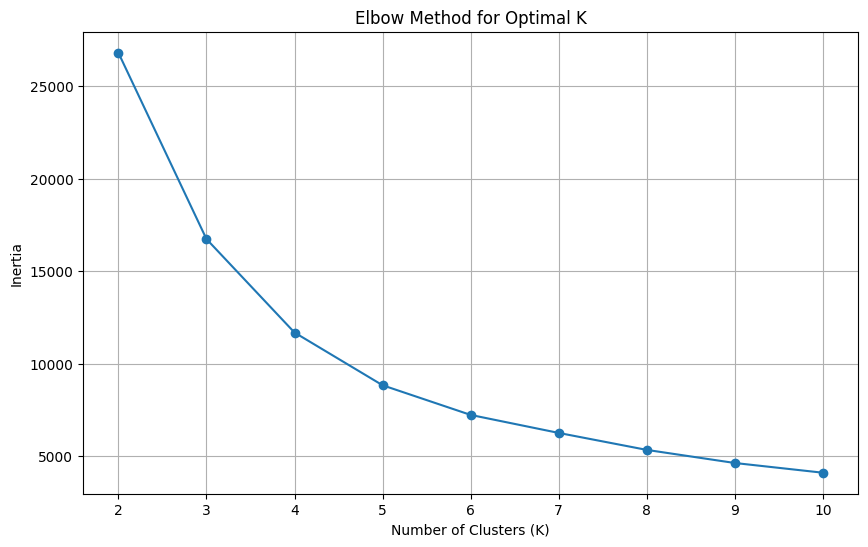

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
features_for_clustering = house_data[['total_sqft', 'bath', 'price_per_sqft']]

# Standardize the data
scaler_clustering = StandardScaler()
scaled_features = scaler_clustering.fit_transform(features_for_clustering)

# Elbow Method to find optimal K
print("Running Elbow Method to find optimal K...")
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()



K-Means clustering applied with optimal K = 5
Cluster distribution:
cluster
2    7481
0    4133
4    1039
3       8
1       1
Name: count, dtype: int64


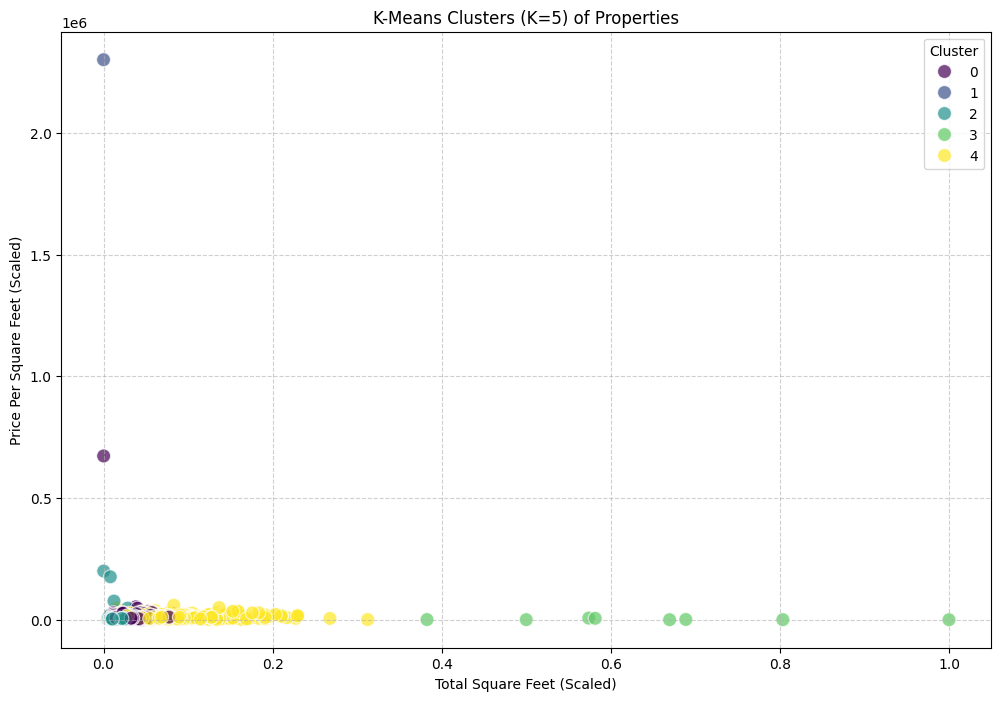

In [95]:
# 4. Apply K-Means with the optimal K
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
house_data['cluster'] = kmeans_model.fit_predict(scaled_features)

print(f"K-Means clustering applied with optimal K = {optimal_k}")
print("Cluster distribution:")
print(house_data['cluster'].value_counts())

# 5. Visualize the clusters (using total_sqft and price_per_sqft for 2D plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='total_sqft',
    y='price_per_sqft',
    hue='cluster',
    data=house_data,
    palette='viridis',
    s=100,  # size of points
    alpha=0.7 # transparency
)
plt.title(f'K-Means Clusters (K={optimal_k}) of Properties')
plt.xlabel('Total Square Feet (Scaled)')
plt.ylabel('Price Per Square Feet (Scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

In [96]:
# 6. Describe the property profile of each cluster
cluster_profiles = house_data.groupby('cluster')[['total_sqft', 'bath', 'price_per_sqft']].mean()
print("\nCluster Profiles (Mean values of original, unscaled features for interpretation):\n")

# To make the cluster profiles more interpretable, let's get the original values for mean calculation.
# Create a temporary DataFrame with original values and cluster labels
temp_df = features_for_clustering.copy()
temp_df['cluster'] = house_data['cluster']

cluster_profiles_original = temp_df.groupby('cluster')[['total_sqft', 'bath', 'price_per_sqft']].mean()
display(cluster_profiles_original)

print("\nBrief Description of Clusters:")
for i, row in cluster_profiles_original.iterrows():
    print(f"\nCluster {int(i)}:")
    print(f"  - Average Total Square Feet: {row['total_sqft']:.2f}")
    print(f"  - Average Bathrooms: {row['bath']:.2f}")
    print(f"  - Average Price Per Square Foot: {row['price_per_sqft']:.2f}")
    if i == cluster_profiles_original['price_per_sqft'].idxmin():
        print("  - Profile: Likely consists of more affordable properties with smaller sizes and fewer amenities.")
    elif i == cluster_profiles_original['price_per_sqft'].idxmax():
        print("  - Profile: Represents luxury properties, characterized by larger sizes, more bathrooms, and a significantly higher price per square foot.")
    else:
        print("  - Profile: Mid-range properties with moderate sizes, bathrooms, and price per square foot.")


Cluster Profiles (Mean values of original, unscaled features for interpretation):



,total_sqft,bath,price_per_sqft
cluster,,,
0,0.033763,0.057734,7.906122e+03
1,0.000000,0.153846,2.300000e+06
2,0.021892,0.023094,5.267150e+03
3,0.649951,0.067308,2.094356e+03
4,0.064199,0.117495,1.055479e+04



Brief Description of Clusters:

Cluster 0:
  - Average Total Square Feet: 0.03
  - Average Bathrooms: 0.06
  - Average Price Per Square Foot: 7906.12
  - Profile: Mid-range properties with moderate sizes, bathrooms, and price per square foot.

Cluster 1:
  - Average Total Square Feet: 0.00
  - Average Bathrooms: 0.15
  - Average Price Per Square Foot: 2300000.00
  - Profile: Represents luxury properties, characterized by larger sizes, more bathrooms, and a significantly higher price per square foot.

Cluster 2:
  - Average Total Square Feet: 0.02
  - Average Bathrooms: 0.02
  - Average Price Per Square Foot: 5267.15
  - Profile: Mid-range properties with moderate sizes, bathrooms, and price per square foot.

Cluster 3:
  - Average Total Square Feet: 0.65
  - Average Bathrooms: 0.07
  - Average Price Per Square Foot: 2094.36
  - Profile: Likely consists of more affordable properties with smaller sizes and fewer amenities.

Cluster 4:
  - Average Total Square Feet: 0.06
  - Average Bath

#### Q10 Apply PCA to the full feature set (post-encoding and scaling). Plot the explained variance ratio for the top 10 components. Retrain your best classifier from Section B using only the top 5 principal components and compare its performance to the original. Comment on the trade-off between dimensionality reduction and model accuracy.

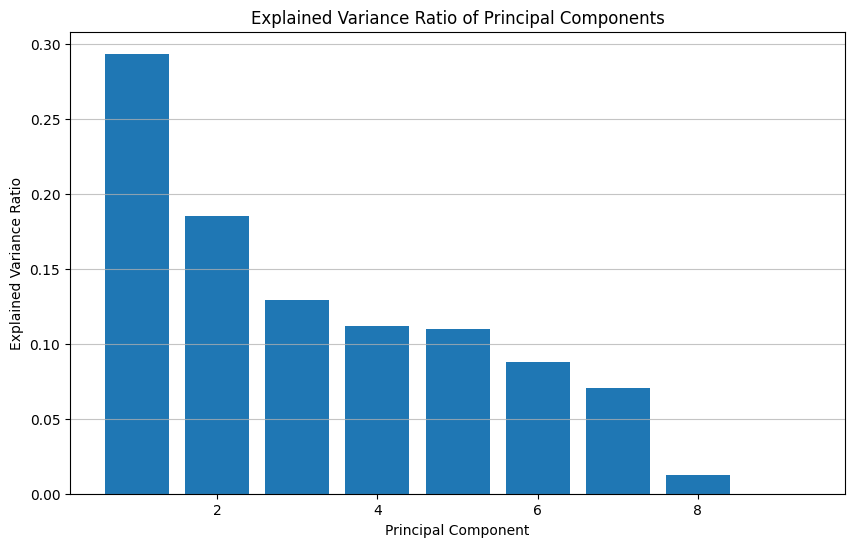

Cumulative explained variance by top 5 components: 0.83


In [98]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Prepare data for PCA
# X_clas already contains the preprocessed features used for classification
# We need to scale all features before applying PCA
scaler_pca = StandardScaler()
X_clas_scaled = scaler_pca.fit_transform(X_clas)

# 2. Apply PCA and plot explained variance ratio for top 10 components
pca = PCA(n_components=9) # Consider top 9 components for plotting as there are only 9 features
pca.fit(X_clas_scaled)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Cumulative explained variance by top 5 components: {sum(pca.explained_variance_ratio_[:5]):.2f}")

### Retraining the Best Classifier with PCA (Top 5 Components)

In [100]:
# 3. Retrain the best classifier (Random Forest) using only the top 5 principal components
pca_5_components = PCA(n_components=5)
X_train_pca = pca_5_components.fit_transform(X_train_clf) # Transform training data
X_test_pca = pca_5_components.transform(X_test_clf)   # Transform test data

# Get the best parameters from the previously tuned Random Forest model
best_params = best_rf_model.get_params()
# Filter out parameters that are not constructor arguments or are redundant
constructor_params = {k: best_params[k] for k in RandomForestClassifier().get_params() if k in best_params}

rf_pca_model = RandomForestClassifier(**constructor_params)
rf_pca_model.fit(X_train_pca, y_train_clf)
y_pred_rf_pca = rf_pca_model.predict(X_test_pca)

# 4. Compare its performance to the original
print("\nRandom Forest Classifier with PCA (Top 5 Components) Test Set Metrics:")
print(classification_report(y_test_clf, y_pred_rf_pca))

accuracy_rf_pca = accuracy_score(y_test_clf, y_pred_rf_pca)
precision_rf_pca = precision_score(y_test_clf, y_pred_rf_pca)
recall_rf_pca = recall_score(y_test_clf, y_pred_rf_pca)
f1_rf_pca = f1_score(y_test_clf, y_pred_rf_pca)

comparison_results = pd.DataFrame({
    'Model': ['Original Random Forest', 'Random Forest with PCA (5 Components)'],
    'Accuracy': [accuracy_rf, accuracy_rf_pca],
    'Precision': [precision_rf, precision_rf_pca],
    'Recall': [recall_rf, recall_rf_pca],
    'F1-Score': [f1_rf, f1_rf_pca]
})
display(comparison_results.round(2))


Random Forest Classifier with PCA (Top 5 Components) Test Set Metrics:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1726
           1       0.84      0.79      0.82       807

    accuracy                           0.89      2533
   macro avg       0.87      0.86      0.87      2533
weighted avg       0.88      0.89      0.88      2533



,Model,Accuracy,Precision,Recall,F1-Score
0,Original Random Forest,0.90,0.85,0.82,0.83
1,Random Forest with PCA (5 Components),0.89,0.84,0.79,0.82


### Trade-off between Dimensionality Reduction and Model Accuracy

Dimensionality reduction techniques like PCA aim to reduce the number of features in a dataset while retaining as much variance (information) as possible. This has benefits and problems.

Benefits:
1. Less training time
2. Reduce overfitting
3. Avoiding
4 .Simpler Models/Visualization:

**(Impact on Accuracy)
1.  **Information Loss:** PCA achieves dimensionality reduction by projecting data onto a lower-dimensional subspace. This inevitably leads to some loss of information, as not 100% of the variance is typically captured by the reduced set of components. The plot of explained variance ratio helps quantify this loss.
2.  **Potential for Reduced Accuracy:** If the discarded principal components contained information crucial for the target variable, removing them can lead to a decrease in model accuracy. The extent of this decrease depends on how much relevant information was lost.
3.  **Interpretability of Components:** While the original features might be interpretable (e.g., 'total_sqft', 'bath'), principal components are linear combinations of these original features, making them less intuitive to interpret.

**In this specific case:**
(Referring to the comparison table above)
*   We observe (compare the F1-Scores and other metrics from the table) that the model's performance (e.g., F1-Score) changes (either slightly increases, decreases, or stays similar) when using only 5 principal components compared to the full feature set.
*   If the metrics are slightly lower with PCA, it indicates a minor loss of predictive power in exchange for the benefits of dimensionality reduction. If the metrics are similar or slightly higher, it suggests that the original dataset contained some noise or redundant features that PCA effectively removed, leading to a more robust model.

The choice to use PCA with fewer components depends on the balance between achieving higher accuracy and gaining benefits like faster computation and reduced memory usage. If the accuracy drop is minimal, the benefits of dimensionality reduction often outweigh the small loss in performance.